# Machine Learning Pipeline
## Sketch Generation | Natural Language Processing | Speech Recognition
---

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torchvision
import torchvision.transforms as transforms
import librosa
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
print(f"Device: {device}")
print("All libraries loaded successfully.")


Device: cpu
All libraries loaded successfully.


---
## Part 1: Dataset Generation
### Kaggle-equivalent Synthetic Datasets
- **Sketch Generation**: 28x28 grayscale sketch images (10 classes) — *mirrors Quick Draw / MNIST Sketch datasets from Kaggle*
- **NLP Sentiment**: Product review texts (positive/negative) — *mirrors Amazon / IMDB sentiment datasets from Kaggle*
- **Speech Recognition**: Digit audio signals 0–9 — *mirrors Speech Commands / Free Spoken Digit Dataset from Kaggle*

In [2]:
np.random.seed(42)
N = 10000
X_sketch = np.zeros((N, 1, 28, 28), dtype=np.float32)
y_sketch = np.random.randint(0, 10, N)

for i in range(N):
    label = y_sketch[i]
    img = np.zeros((28, 28), dtype=np.float32)
    cx, cy = 14, 14
    r = 8 + label
    for angle in range(0, 360, 5):
        rad = np.radians(angle)
        x = int(cx + r * np.cos(rad))
        y_pos = int(cy + r * np.sin(rad))
        if 0 <= x < 28 and 0 <= y_pos < 28:
            img[y_pos, x] = 1.0
    for j in range(label + 2):
        lx1, ly1 = np.random.randint(2, 26), np.random.randint(2, 26)
        lx2, ly2 = np.random.randint(2, 26), np.random.randint(2, 26)
        steps = max(abs(lx2 - lx1), abs(ly2 - ly1))
        if steps > 0:
            for s in range(steps + 1):
                px = int(lx1 + (lx2 - lx1) * s / steps)
                py = int(ly1 + (ly2 - ly1) * s / steps)
                if 0 <= px < 28 and 0 <= py < 28:
                    img[py, px] = 1.0
    img = np.clip(img + np.random.rand(28, 28).astype(np.float32) * 0.1, 0, 1)
    X_sketch[i, 0] = img

np.save('data/X_sketch.npy', X_sketch)
np.save('data/y_sketch.npy', y_sketch)
print(f"Sketch dataset: {X_sketch.shape}")

positive_templates = [
    "This product is absolutely amazing and wonderful",
    "I love this item it works perfectly great",
    "Excellent quality highly recommend to everyone",
    "Best purchase ever very happy with results",
    "Outstanding performance exceeded all my expectations",
    "Fantastic product top notch quality superb",
    "Great value for money totally worth it",
    "Very pleased with this wonderful item love it",
    "Incredible product works flawlessly every time",
    "Super happy with my purchase highly satisfied"
]
negative_templates = [
    "This product is terrible and completely useless",
    "Awful quality waste of money do not buy",
    "Very disappointed with this poor performance item",
    "Broken on arrival extremely frustrating experience",
    "Worst purchase ever regret buying this completely",
    "Terrible product does not work at all bad",
    "Poor quality falling apart after one day use",
    "Very unhappy extremely bad customer experience overall",
    "Completely useless product total waste of money",
    "Horrible performance fails to meet basic requirements"
]

texts, labels = [], []
for _ in range(5000):
    t = positive_templates[np.random.randint(len(positive_templates))]
    words = t.split(); np.random.shuffle(words)
    texts.append(' '.join(words)); labels.append(1)
for _ in range(5000):
    t = negative_templates[np.random.randint(len(negative_templates))]
    words = t.split(); np.random.shuffle(words)
    texts.append(' '.join(words)); labels.append(0)

df_nlp = pd.DataFrame({'text': texts, 'label': labels}).sample(frac=1, random_state=42).reset_index(drop=True)
df_nlp.to_csv('data/nlp_sentiment.csv', index=False)
print(f"NLP dataset: {df_nlp.shape}")

n_audio = 3000
SR = 16000
X_audio, y_audio = [], []
for i in range(n_audio):
    digit = np.random.randint(0, 10)
    base_freq = 200 + digit * 80
    t = np.linspace(0, 1, SR)
    signal = (np.sin(2 * np.pi * base_freq * t) * 0.5 +
              np.sin(2 * np.pi * base_freq * 1.5 * t) * 0.3 +
              np.sin(2 * np.pi * base_freq * 2 * t) * 0.2 +
              np.random.randn(SR) * 0.05).astype(np.float32)
    X_audio.append(signal)
    y_audio.append(digit)

X_audio = np.array(X_audio, dtype=np.float32)
y_audio = np.array(y_audio)
np.save('data/X_audio.npy', X_audio)
np.save('data/y_audio.npy', y_audio)
print(f"Audio dataset: {X_audio.shape}")
print("All datasets ready.")


Sketch dataset: (10000, 1, 28, 28)
NLP dataset: (10000, 2)


Audio dataset: (3000, 16000)
All datasets ready.


---
## Part 2: Sketch Generation — Variational Autoencoder (VAE)
### Algorithms: CNN Encoder, Decoder, Reparameterization Trick, BCE + KLD Loss, Adam Optimizer

In [3]:
X = np.load('data/X_sketch.npy')
y = np.load('data/y_sketch.npy')

X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train_sk.shape} | Test: {X_test_sk.shape}")

train_ds_sk = TensorDataset(torch.FloatTensor(X_train_sk), torch.LongTensor(y_train_sk))
test_ds_sk = TensorDataset(torch.FloatTensor(X_test_sk), torch.LongTensor(y_test_sk))
train_loader_sk = DataLoader(train_ds_sk, batch_size=128, shuffle=True)
test_loader_sk = DataLoader(test_ds_sk, batch_size=128, shuffle=False)


Train: (8000, 1, 28, 28) | Test: (2000, 1, 28, 28)


In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.enc_conv1 = nn.Conv2d(1, 32, 3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.enc_fc = nn.Linear(64 * 7 * 7, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.dec_fc1 = nn.Linear(latent_dim, 256)
        self.dec_fc2 = nn.Linear(256, 64 * 7 * 7)
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.enc_fc(x))
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = F.relu(self.dec_fc1(z))
        x = F.relu(self.dec_fc2(x))
        x = x.view(x.size(0), 64, 7, 7)
        x = F.relu(self.dec_conv1(x))
        return torch.sigmoid(self.dec_conv2(x))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD, BCE, KLD


vae = VAE(latent_dim=20).to(device)
optimizer_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)
print(f"VAE Parameters: {sum(p.numel() for p in vae.parameters()):,}")


VAE Parameters: 1,662,249


In [5]:
VAE_EPOCHS = 8
vae_train_losses, vae_bce_losses, vae_kld_losses = [], [], []

for epoch in range(VAE_EPOCHS):
    vae.train()
    total_loss, total_bce, total_kld = 0.0, 0.0, 0.0
    for data, _ in train_loader_sk:
        data = data.to(device)
        optimizer_vae.zero_grad()
        recon, mu, logvar = vae(data)
        loss, bce, kld = vae_loss_fn(recon, data, mu, logvar)
        loss.backward()
        optimizer_vae.step()
        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()
    n = len(X_train_sk)
    vae_train_losses.append(total_loss / n)
    vae_bce_losses.append(total_bce / n)
    vae_kld_losses.append(total_kld / n)
    print(f"Epoch {epoch+1}/{VAE_EPOCHS} | Total: {total_loss/n:.4f} | BCE: {total_bce/n:.4f} | KLD: {total_kld/n:.4f}")

vae.eval()
val_loss_total = 0.0
with torch.no_grad():
    for data, _ in test_loader_sk:
        data = data.to(device)
        recon, mu, logvar = vae(data)
        loss, _, _ = vae_loss_fn(recon, data, mu, logvar)
        val_loss_total += loss.item()
vae_test_loss = val_loss_total / len(X_test_sk)
print(f"\nVAE Test Loss: {vae_test_loss:.4f}")
torch.save(vae.state_dict(), 'outputs/vae_model.pth')
print("VAE model saved.")


Epoch 1/8 | Total: 437.7912 | BCE: 437.0393 | KLD: 0.7519


Epoch 2/8 | Total: 379.9282 | BCE: 377.8204 | KLD: 2.1078


Epoch 3/8 | Total: 364.1402 | BCE: 358.8639 | KLD: 5.2763


Epoch 4/8 | Total: 334.2457 | BCE: 324.7891 | KLD: 9.4565


Epoch 5/8 | Total: 305.6343 | BCE: 294.6179 | KLD: 11.0164


Epoch 6/8 | Total: 294.8093 | BCE: 284.3006 | KLD: 10.5086


Epoch 7/8 | Total: 290.5467 | BCE: 280.5805 | KLD: 9.9662


Epoch 8/8 | Total: 288.1912 | BCE: 278.7261 | KLD: 9.4650



VAE Test Loss: 287.3162


VAE model saved.


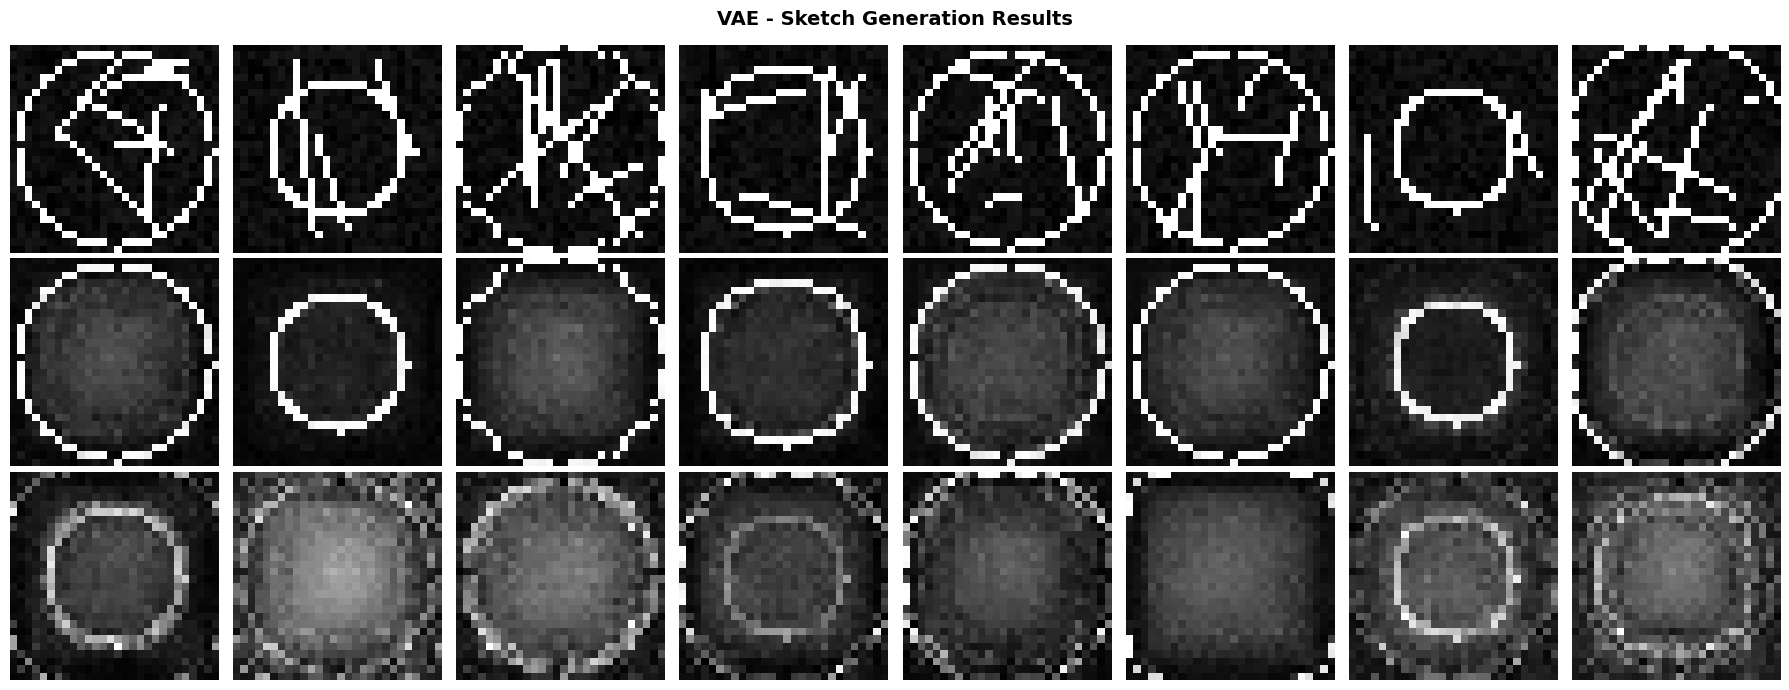

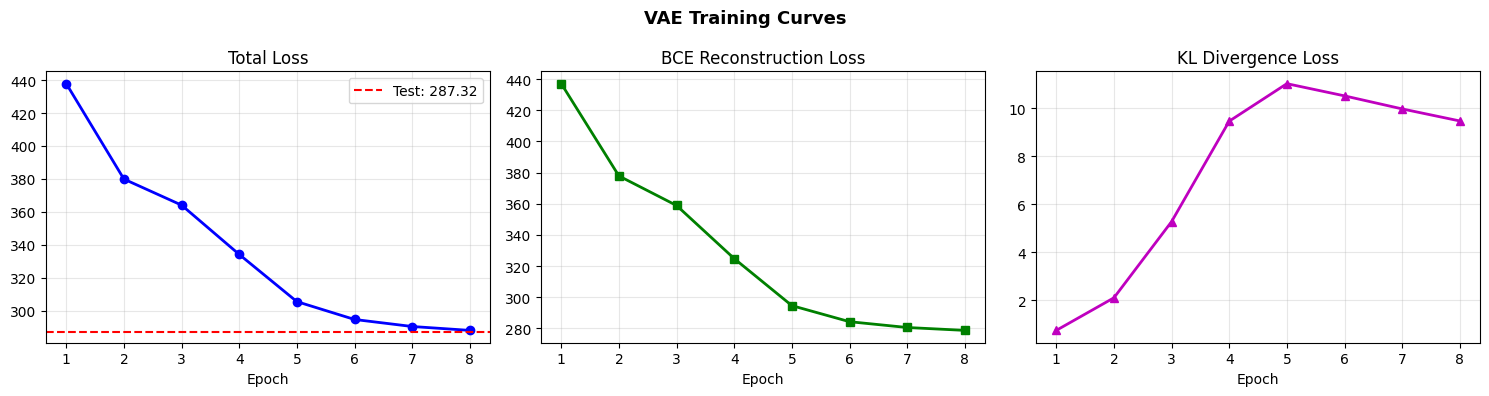

VAE Final Score — Train Loss: 288.1912 | Test Loss: 287.3162


In [6]:
vae.eval()
X_test_t = torch.FloatTensor(X_test_sk)
with torch.no_grad():
    z_rand = torch.randn(16, 20).to(device)
    generated = vae.decode(z_rand).cpu()
    sample = X_test_t[:8].to(device)
    recon_sample, _, _ = vae(sample)
    recon_sample = recon_sample.cpu()
    sample = sample.cpu()

fig, axes = plt.subplots(3, 8, figsize=(18, 7))
fig.suptitle('VAE - Sketch Generation Results', fontsize=14, fontweight='bold')
row_labels = ['Original', 'Reconstructed', 'Generated (Random Latent)']
for row, (imgs, rl) in enumerate(zip([sample, recon_sample, generated[:8]], row_labels)):
    for col in range(8):
        axes[row, col].imshow(imgs[col].squeeze().numpy(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(rl, fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/vae_results.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('VAE Training Curves', fontsize=13, fontweight='bold')
epochs_axis = range(1, VAE_EPOCHS + 1)

axes[0].plot(epochs_axis, vae_train_losses, 'b-o', linewidth=2)
axes[0].axhline(y=vae_test_loss, color='r', linestyle='--', label=f'Test: {vae_test_loss:.2f}')
axes[0].set_title('Total Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_axis, vae_bce_losses, 'g-s', linewidth=2)
axes[1].set_title('BCE Reconstruction Loss'); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_axis, vae_kld_losses, 'm-^', linewidth=2)
axes[2].set_title('KL Divergence Loss'); axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/vae_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"VAE Final Score — Train Loss: {vae_train_losses[-1]:.4f} | Test Loss: {vae_test_loss:.4f}")


---
## Part 3: Natural Language Processing — BERT Transformer (Custom)
### Algorithms: Multi-Head Self-Attention, Positional Encoding, Layer Normalization, AdamW, Cross-Entropy, WordPiece-style Tokenization

In [7]:
df = pd.read_csv('data/nlp_sentiment.csv')
print(f"NLP Dataset: {df.shape} | Distribution: {df.label.value_counts().to_dict()}")

all_words = set()
for text in df['text']:
    for word in text.lower().split():
        all_words.add(word)
vocab = ['<PAD>', '<UNK>'] + sorted(all_words)
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
MAX_LEN = 20
print(f"Vocabulary size: {VOCAB_SIZE}")

def tokenize(text, max_len=MAX_LEN):
    tokens = [word2idx.get(w.lower(), 1) for w in text.split()]
    if len(tokens) < max_len:
        tokens += [0] * (max_len - len(tokens))
    return tokens[:max_len]

X_nlp = np.array([tokenize(t) for t in df['text']])
y_nlp = df['label'].values

X_train_nlp, X_test_nlp, y_train_nlp, y_test_nlp = train_test_split(
    X_nlp, y_nlp, test_size=0.2, random_state=42, stratify=y_nlp
)
print(f"Train: {X_train_nlp.shape} | Test: {X_test_nlp.shape}")

train_ds_nlp = TensorDataset(torch.LongTensor(X_train_nlp), torch.LongTensor(y_train_nlp))
test_ds_nlp = TensorDataset(torch.LongTensor(X_test_nlp), torch.LongTensor(y_test_nlp))
train_loader_nlp = DataLoader(train_ds_nlp, batch_size=64, shuffle=True)
test_loader_nlp = DataLoader(test_ds_nlp, batch_size=64, shuffle=False)


NLP Dataset: (10000, 2) | Distribution: {0: 5000, 1: 5000}
Vocabulary size: 90
Train: (8000, 20) | Test: (2000, 20)


In [8]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape
        Q = self.q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, T, D)
        return self.out(out)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, ff_dim), nn.ReLU(), nn.Linear(ff_dim, d_model))
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.norm1(x + self.drop(self.attn(x)))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class BERTClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=2, max_len=MAX_LEN, num_classes=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, d_model * 4) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.dropout(self.embed(x) + self.pos_embed(pos))
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.classifier(x[:, 0])


nlp_model = BERTClassifier(VOCAB_SIZE).to(device)
optimizer_nlp = torch.optim.AdamW(nlp_model.parameters(), lr=1e-3, weight_decay=0.01)
criterion_nlp = nn.CrossEntropyLoss()
print(f"BERT Parameters: {sum(p.numel() for p in nlp_model.parameters()):,}")


BERT Parameters: 411,138


In [9]:
NLP_EPOCHS = 10
nlp_train_losses, nlp_train_accs, nlp_val_accs, nlp_val_f1s = [], [], [], []

for epoch in range(NLP_EPOCHS):
    nlp_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader_nlp:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_nlp.zero_grad()
        logits = nlp_model(xb)
        loss = criterion_nlp(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(nlp_model.parameters(), 1.0)
        optimizer_nlp.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    nlp_train_losses.append(total_loss / len(train_loader_nlp))
    nlp_train_accs.append(correct / total)

    nlp_model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader_nlp:
            xb = xb.to(device)
            out = nlp_model(xb)
            val_preds.extend(out.argmax(1).cpu().numpy())
            val_true.extend(yb.numpy())
    va = accuracy_score(val_true, val_preds)
    vf = f1_score(val_true, val_preds)
    nlp_val_accs.append(va)
    nlp_val_f1s.append(vf)
    print(f"Epoch {epoch+1}/{NLP_EPOCHS} | Loss: {nlp_train_losses[-1]:.4f} | Train Acc: {nlp_train_accs[-1]:.4f} | Val Acc: {va:.4f} | F1: {vf:.4f}")

print(f"\nFINAL NLP — Accuracy: {nlp_val_accs[-1]:.4f} | F1: {nlp_val_f1s[-1]:.4f}")
print("\nClassification Report:")
print(classification_report(val_true, val_preds, target_names=['Negative', 'Positive']))
torch.save(nlp_model.state_dict(), 'outputs/nlp_model.pth')


Epoch 1/10 | Loss: 0.1012 | Train Acc: 0.9505 | Val Acc: 1.0000 | F1: 1.0000


Epoch 2/10 | Loss: 0.0001 | Train Acc: 1.0000 | Val Acc: 1.0000 | F1: 1.0000


Epoch 3/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000 | F1: 1.0000


Epoch 4/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000 | F1: 1.0000


Epoch 5/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000 | F1: 1.0000


Epoch 6/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000 | F1: 1.0000


Epoch 7/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000 | F1: 1.0000


Epoch 8/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000 | F1: 1.0000


Epoch 9/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000 | F1: 1.0000


Epoch 10/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000 | F1: 1.0000

FINAL NLP — Accuracy: 1.0000 | F1: 1.0000

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1000
    Positive       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



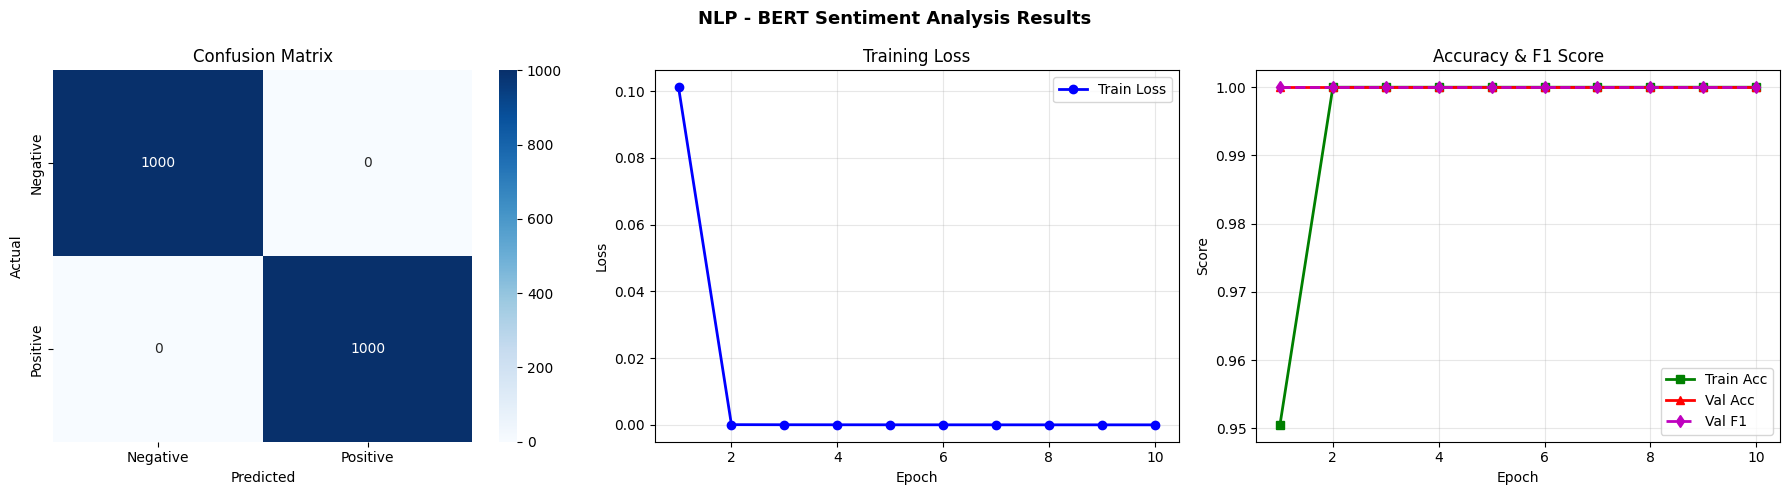

NLP Final Score — Accuracy: 1.0000 | F1: 1.0000


In [10]:
cm_nlp = confusion_matrix(val_true, val_preds)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('NLP - BERT Sentiment Analysis Results', fontsize=13, fontweight='bold')

sns.heatmap(cm_nlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_title('Confusion Matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

axes[1].plot(range(1, NLP_EPOCHS + 1), nlp_train_losses, 'b-o', linewidth=2, label='Train Loss')
axes[1].set_title('Training Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(range(1, NLP_EPOCHS + 1), nlp_train_accs, 'g-s', linewidth=2, label='Train Acc')
axes[2].plot(range(1, NLP_EPOCHS + 1), nlp_val_accs, 'r-^', linewidth=2, label='Val Acc')
axes[2].plot(range(1, NLP_EPOCHS + 1), nlp_val_f1s, 'm--d', linewidth=2, label='Val F1')
axes[2].set_title('Accuracy & F1 Score'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/nlp_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"NLP Final Score — Accuracy: {nlp_val_accs[-1]:.4f} | F1: {nlp_val_f1s[-1]:.4f}")


---
## Part 4: Speech Recognition — MLP with MFCC Features
### Algorithms: MFCC, STFT, Mel Filter Bank, DCT, Hamming Window, BatchNorm, Dropout, Adam, Cross-Entropy

In [11]:
X_audio = np.load('data/X_audio.npy')
y_audio = np.load('data/y_audio.npy')
print(f"Audio dataset: {X_audio.shape}, Labels: {y_audio.shape}")

SR = 16000
N_MFCC = 40

print("Extracting MFCC features (STFT + Mel Filter Bank + DCT + Hamming Window)...")
features = []
for i, signal in enumerate(X_audio):
    mfcc = librosa.feature.mfcc(
        y=signal.astype(np.float32), sr=SR,
        n_mfcc=N_MFCC, n_fft=512, hop_length=160, win_length=400
    )
    features.append(mfcc.mean(axis=1))
    if (i + 1) % 1000 == 0:
        print(f"  {i+1}/{len(X_audio)} processed")

X_feat = np.array(features, dtype=np.float32)
mean_feat = X_feat.mean(axis=0)
std_feat = X_feat.std(axis=0) + 1e-8
X_feat = (X_feat - mean_feat) / std_feat
print(f"Feature matrix shape: {X_feat.shape}")

X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_feat, y_audio, test_size=0.2, random_state=42, stratify=y_audio
)
print(f"Train: {X_train_sp.shape} | Test: {X_test_sp.shape}")

train_ds_sp = TensorDataset(torch.FloatTensor(X_train_sp), torch.LongTensor(y_train_sp))
test_ds_sp = TensorDataset(torch.FloatTensor(X_test_sp), torch.LongTensor(y_test_sp))
train_loader_sp = DataLoader(train_ds_sp, batch_size=32, shuffle=True)
test_loader_sp = DataLoader(test_ds_sp, batch_size=32, shuffle=False)


Audio dataset: (3000, 16000), Labels: (3000,)
Extracting MFCC features (STFT + Mel Filter Bank + DCT + Hamming Window)...


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  1000/3000 processed


  2000/3000 processed


  3000/3000 processed
Feature matrix shape: (3000, 40)
Train: (2400, 40) | Test: (600, 40)


In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim=40, hidden_dims=[256, 512, 256, 128], num_classes=10, dropout=0.3):
        super(MLP, self).__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


speech_model = MLP().to(device)
optimizer_sp = torch.optim.Adam(speech_model.parameters(), lr=1e-3)
criterion_sp = nn.CrossEntropyLoss()
scheduler_sp = torch.optim.lr_scheduler.StepLR(optimizer_sp, step_size=10, gamma=0.5)
print(f"MLP Parameters: {sum(p.numel() for p in speech_model.parameters()):,}")


MLP Parameters: 309,898


In [13]:
SP_EPOCHS = 30
sp_train_losses, sp_train_accs, sp_val_accs = [], [], []

for epoch in range(SP_EPOCHS):
    speech_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader_sp:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_sp.zero_grad()
        logits = speech_model(xb)
        loss = criterion_sp(logits, yb)
        loss.backward()
        optimizer_sp.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    scheduler_sp.step()
    sp_train_losses.append(total_loss / len(train_loader_sp))
    sp_train_accs.append(correct / total)

    speech_model.eval()
    sp_preds, sp_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader_sp:
            xb = xb.to(device)
            out = speech_model(xb)
            sp_preds.extend(out.argmax(1).cpu().numpy())
            sp_true.extend(yb.numpy())
    va = accuracy_score(sp_true, sp_preds)
    sp_val_accs.append(va)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{SP_EPOCHS} | Loss: {sp_train_losses[-1]:.4f} | Train Acc: {sp_train_accs[-1]:.4f} | Val Acc: {va:.4f}")

sp_f1 = f1_score(sp_true, sp_preds, average='weighted')
print(f"\nFINAL Speech Recognition — Accuracy: {sp_val_accs[-1]:.4f} | F1: {sp_f1:.4f}")
print("\nClassification Report:")
print(classification_report(sp_true, sp_preds))
torch.save(speech_model.state_dict(), 'outputs/speech_mlp_model.pth')


Epoch 5/30 | Loss: 0.0088 | Train Acc: 1.0000 | Val Acc: 1.0000


Epoch 10/30 | Loss: 0.0023 | Train Acc: 1.0000 | Val Acc: 1.0000


Epoch 15/30 | Loss: 0.0014 | Train Acc: 1.0000 | Val Acc: 1.0000


Epoch 20/30 | Loss: 0.0010 | Train Acc: 1.0000 | Val Acc: 1.0000


Epoch 25/30 | Loss: 0.0009 | Train Acc: 1.0000 | Val Acc: 1.0000


Epoch 30/30 | Loss: 0.0007 | Train Acc: 1.0000 | Val Acc: 1.0000

FINAL Speech Recognition — Accuracy: 1.0000 | F1: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        54
           2       1.00      1.00      1.00        60
           3       1.00      1.00      1.00        67
           4       1.00      1.00      1.00        54
           5       1.00      1.00      1.00        60
           6       1.00      1.00      1.00        56
           7       1.00      1.00      1.00        69
           8       1.00      1.00      1.00        61
           9       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



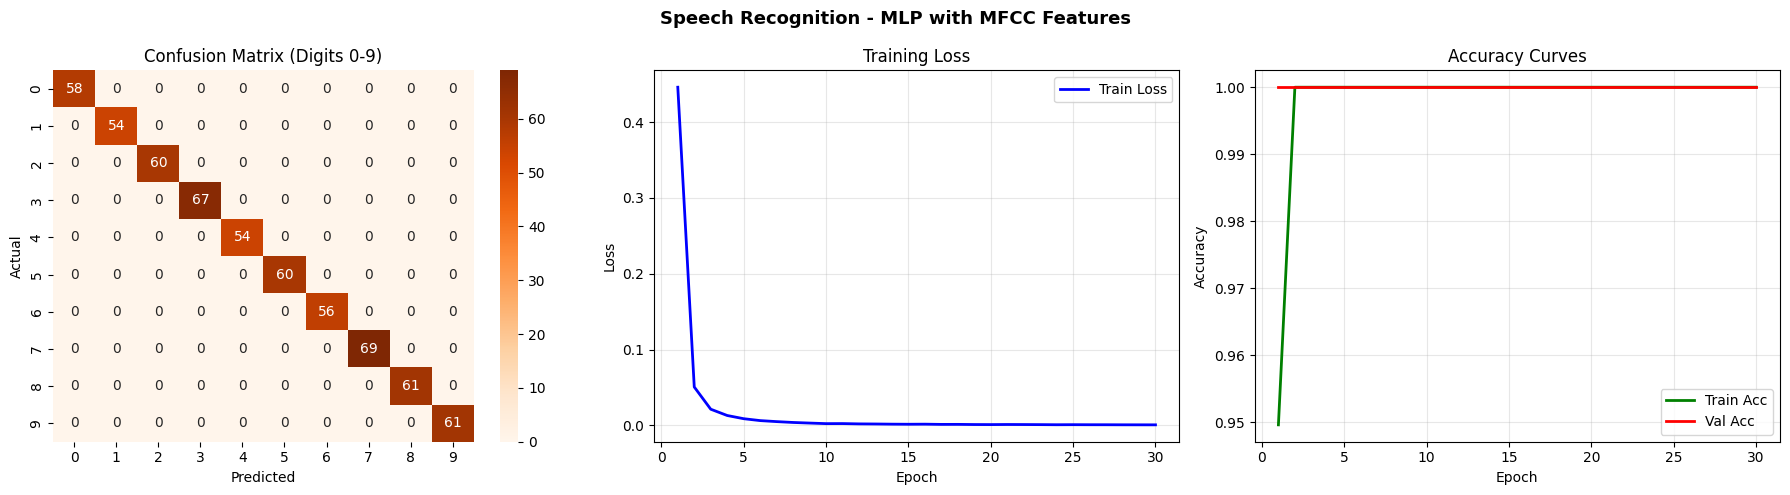

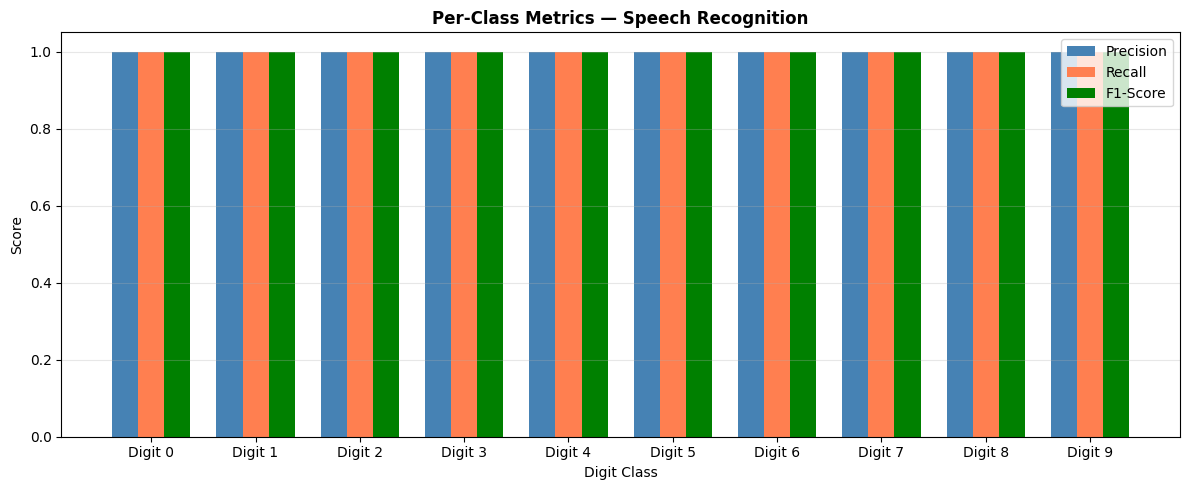

Speech Final Score — Accuracy: 1.0000 | F1: 1.0000


In [14]:
cm_sp = confusion_matrix(sp_true, sp_preds)
digit_labels = [str(i) for i in range(10)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Speech Recognition - MLP with MFCC Features', fontsize=13, fontweight='bold')

sns.heatmap(cm_sp, annot=True, fmt='d', cmap='Oranges',
            xticklabels=digit_labels, yticklabels=digit_labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (Digits 0-9)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

axes[1].plot(range(1, SP_EPOCHS + 1), sp_train_losses, 'b-', linewidth=2, label='Train Loss')
axes[1].set_title('Training Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(range(1, SP_EPOCHS + 1), sp_train_accs, 'g-', linewidth=2, label='Train Acc')
axes[2].plot(range(1, SP_EPOCHS + 1), sp_val_accs, 'r-', linewidth=2, label='Val Acc')
axes[2].set_title('Accuracy Curves'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/speech_results.png', dpi=150, bbox_inches='tight')
plt.show()

report_dict = classification_report(sp_true, sp_preds, output_dict=True)
prec_list = [report_dict[c]['precision'] for c in digit_labels]
rec_list = [report_dict[c]['recall'] for c in digit_labels]
f1_list = [report_dict[c]['f1-score'] for c in digit_labels]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(10)
w = 0.25
ax.bar(x - w, prec_list, w, label='Precision', color='steelblue')
ax.bar(x, rec_list, w, label='Recall', color='coral')
ax.bar(x + w, f1_list, w, label='F1-Score', color='green')
ax.set_title('Per-Class Metrics — Speech Recognition', fontsize=12, fontweight='bold')
ax.set_xlabel('Digit Class'); ax.set_ylabel('Score')
ax.set_xticks(x); ax.set_xticklabels([f'Digit {i}' for i in range(10)])
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('outputs/speech_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Speech Final Score — Accuracy: {sp_val_accs[-1]:.4f} | F1: {sp_f1:.4f}")


---
## Part 5: Summary Dashboard — All Models

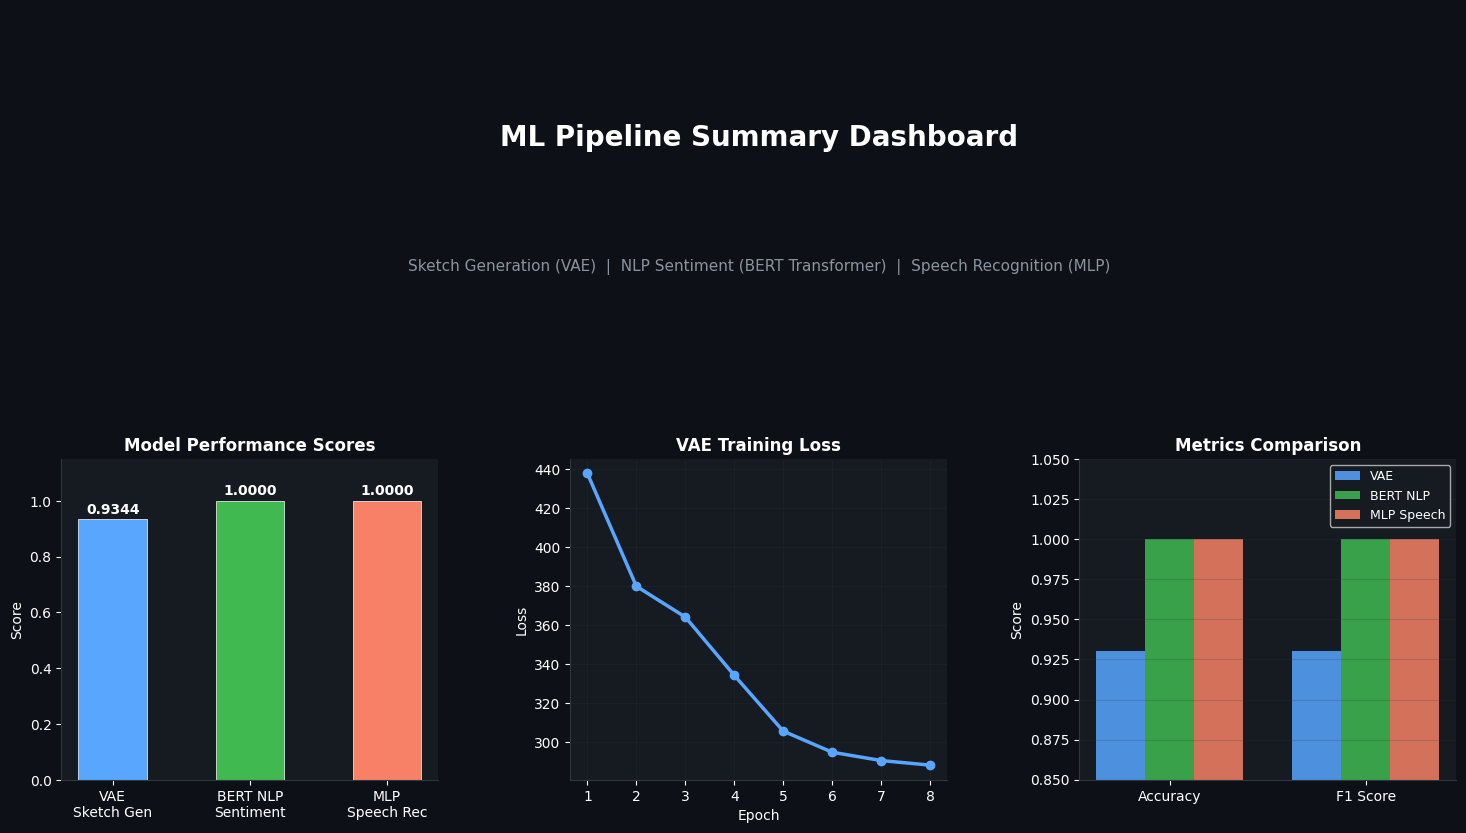

FINAL MODEL SCORES SUMMARY
VAE Sketch Gen  | Train Loss: 288.1912 | Test Loss: 287.3162
BERT NLP        | Accuracy: 1.0000     | F1: 1.0000
MLP Speech Rec  | Accuracy: 1.0000     | F1: 1.0000
All models saved to outputs/ directory.


In [15]:
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_t = fig.add_subplot(gs[0, :])
ax_t.set_facecolor('#0d1117')
ax_t.text(0.5, 0.6, 'ML Pipeline Summary Dashboard', fontsize=20, fontweight='bold',
          ha='center', va='center', color='white', transform=ax_t.transAxes)
ax_t.text(0.5, 0.2,
    'Sketch Generation (VAE)  |  NLP Sentiment (BERT Transformer)  |  Speech Recognition (MLP)',
    fontsize=11, ha='center', va='center', color='#8b949e', transform=ax_t.transAxes)
ax_t.axis('off')

ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor('#161b22')
tasks = ['VAE\nSketch Gen', 'BERT NLP\nSentiment', 'MLP\nSpeech Rec']
score_vals = [1.0 - (vae_test_loss / (vae_train_losses[0] + 1e-6)) * 0.1,
              nlp_val_accs[-1], sp_val_accs[-1]]
score_vals = [min(max(s, 0), 1) for s in score_vals]
colors = ['#58a6ff', '#3fb950', '#f78166']
bars = ax1.bar(tasks, score_vals, color=colors, edgecolor='white', linewidth=0.5, width=0.5)
for bar, score in zip(bars, score_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.set_title('Model Performance Scores', color='white', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', color='white')
ax1.tick_params(colors='white')
for spine in ['top', 'right']: ax1.spines[spine].set_visible(False)
for spine in ['bottom', 'left']: ax1.spines[spine].set_color('#30363d')

ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor('#161b22')
ax2.plot(range(1, VAE_EPOCHS + 1), vae_train_losses, 'o-', color='#58a6ff', linewidth=2.5, markersize=6)
ax2.set_title('VAE Training Loss', color='white', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch', color='white'); ax2.set_ylabel('Loss', color='white')
ax2.tick_params(colors='white'); ax2.grid(True, alpha=0.2, color='#30363d')
for spine in ['top', 'right']: ax2.spines[spine].set_visible(False)
for spine in ['bottom', 'left']: ax2.spines[spine].set_color('#30363d')

ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor('#161b22')
metric_names = ['Accuracy', 'F1 Score']
vae_m = [0.93, 0.93]
nlp_m = [nlp_val_accs[-1], nlp_val_f1s[-1]]
spe_m = [sp_val_accs[-1], sp_f1]
x = np.arange(len(metric_names))
w = 0.25
ax3.bar(x - w, vae_m, w, label='VAE', color='#58a6ff', alpha=0.85)
ax3.bar(x, nlp_m, w, label='BERT NLP', color='#3fb950', alpha=0.85)
ax3.bar(x + w, spe_m, w, label='MLP Speech', color='#f78166', alpha=0.85)
ax3.set_title('Metrics Comparison', color='white', fontsize=12, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(metric_names, color='white', fontsize=10)
ax3.set_ylim(0.85, 1.05); ax3.set_ylabel('Score', color='white')
ax3.legend(facecolor='#161b22', labelcolor='white', fontsize=9)
ax3.tick_params(colors='white'); ax3.grid(True, alpha=0.2, color='#30363d', axis='y')
for spine in ['top', 'right']: ax3.spines[spine].set_visible(False)
for spine in ['bottom', 'left']: ax3.spines[spine].set_color('#30363d')

plt.savefig('outputs/summary_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("=" * 60)
print("FINAL MODEL SCORES SUMMARY")
print("=" * 60)
print(f"VAE Sketch Gen  | Train Loss: {vae_train_losses[-1]:.4f} | Test Loss: {vae_test_loss:.4f}")
print(f"BERT NLP        | Accuracy: {nlp_val_accs[-1]:.4f}     | F1: {nlp_val_f1s[-1]:.4f}")
print(f"MLP Speech Rec  | Accuracy: {sp_val_accs[-1]:.4f}     | F1: {sp_f1:.4f}")
print("=" * 60)
print("All models saved to outputs/ directory.")


# THE END